Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa López (23764)

# Laboratorio 4 (Parte 2) — Modelos de Machine Learning

Este notebook cubre los **ejercicios 4 al 10** de la segunda parte del laboratorio:

4. Construcción de tres modelos de clasificación.
5. Evaluación y comparación de los modelos.
6. Validación espacial por bloques y validación temporal.
7. Generalización entre lagos.
8. Interpretación y explicabilidad con SHAP.
9. Generación de mapas predictivos.
10. Análisis y conclusiones.

Inicia a patrir del conjunto de datos construido en `03_preparacion_dataset_ml.ipynb` y guardado en `data/processed/dataset_ml.csv`, documentado en `codebook.md`.

**Preparación del entorno**

In [1]:
import sys
import warnings
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# La carpeta src/ contiene los scripts
sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
import dataset_ml as dml
import mapas as mp
import procesar

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

SEMILLA = 42
LAGOS = list(config.FECHAS)
COLOR = {"Atitlan": "#1f77b4", "Amatitlan": "#d62728"}

datos = dml.cargar_dataset()
print("Observaciones:", f"{len(datos):,}")
print("Predictores  :", len(dml.PREDICTORES))
print("Prevalencia  :", f"{datos['y_alta'].mean() * 100:.3f} %")

Observaciones: 401,656
Predictores  : 13
Prevalencia  : 1.213 %


---

## Ejercicio 4 — Construcción de modelos de Machine Learning

### 4.2 División de los datos

Se separa el 70% para entrenamiento y el 30% para prueba, con **estratificación** por la variable respuesta. La estratificación es indispensable, con una prevalencia del 1.21%, una división puramente aleatoria podría dejar muy pocos positivos en alguno de los dos conjuntos.

Este conjunto de prueba se guarda y **se reutiliza sin modificar** en todo el ejercicio 5, para que las comparaciones entre modelos sean justas.

In [2]:
X = datos[dml.PREDICTORES]
y = datos["y_alta"]

X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEMILLA
)
# Los identificadores se dividen con los mismos indices, para poder rastrear cada
# observacion de prueba hasta su lago, fecha y posicion.
meta_prueba = datos.loc[X_prueba.index, ["lago", "fecha", "fila", "columna", "bloque_1km", "chla"]]

particion = pd.DataFrame(
    {
        "observaciones": [len(X_ent), len(X_prueba)],
        "positivos": [int(y_ent.sum()), int(y_prueba.sum())],
        "prevalencia_pct": [round(y_ent.mean() * 100, 4), round(y_prueba.mean() * 100, 4)],
    },
    index=["entrenamiento (70 %)", "prueba (30 %)"],
)
particion

,observaciones,positivos,prevalencia_pct
entrenamiento (70 %),281159,3411,1.2132
prueba (30 %),120497,1462,1.2133


### 4.1 y 4.3 Definición de los modelos y ajuste de hiperparámetros

Se construyen los tres modelos solicitados. Los tres reciben `class_weight="balanced"`, que pondera cada clase de forma inversamente proporcional a su frecuencia; sin eso, la función de pérdida quedaría dominada por el 98.79% de negativos.

| Modelo | Por qué se incluye | Hiperparámetros ajustados |
| --- | --- | --- |
| **Regresión Logística** | Modelo lineal de referencia. Sirve de base, si un modelo complejo no lo supera, la complejidad no aporta. Necesita `StandardScaler` porque las variables viven en escalas muy distintas (reflectancias de 0 a 1 frente a distancias de hasta 3 660 m). | `C`, la inversa de la fuerza de regularización. Importa por la fuerte colinealidad detectada en el ejercicio 1.5. |
| **Random Forest** | Captura interacciones y relaciones no lineales, y tolera bien la redundancia entre variables. | `max_depth` y `min_samples_leaf`. Se regulariza desde el inicio. |
| **Gradient Boosting** | `HistGradientBoostingClassifier`, la implementación por histogramas de scikit-learn. Es el equivalente a LightGBM dentro de la librería. | `learning_rate` y `max_leaf_nodes`, que gobiernan el compromiso entre velocidad de aprendizaje y complejidad de cada árbol. |

El criterio de selección es la **precisión promedio** (`average_precision`, equivalente al área bajo la curva de precisión-recall). Se prefiere al accuracy y al ROC-AUC porque es la métrica que no se deja engañar por el desbalance. La validación cruzada interna usa 3 particiones estratificadas.

In [3]:
cv_interna = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA)

configuraciones = {
    "Regresion Logistica": (
        make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEMILLA),
        ),
        {"logisticregression__C": [0.1, 1.0, 10.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=100, class_weight="balanced", n_jobs=2, random_state=SEMILLA
        ),
        {"max_depth": [10, 15], "min_samples_leaf": [20, 50]},
    ),
    "Gradient Boosting": (
        HistGradientBoostingClassifier(class_weight="balanced", random_state=SEMILLA),
        {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [31, 63]},
    ),
}

modelos = {}
busquedas = []
for nombre, (estimador, rejilla) in configuraciones.items():
    busqueda = GridSearchCV(
        estimador, rejilla, scoring="average_precision", cv=cv_interna, n_jobs=1, refit=True
    )
    busqueda.fit(X_ent, y_ent)
    modelos[nombre] = busqueda.best_estimator_
    busquedas.append(
        {
            "modelo": nombre,
            "combinaciones": len(busqueda.cv_results_["params"]),
            "mejores_hiperparametros": busqueda.best_params_,
            "pr_auc_validacion": round(busqueda.best_score_, 4),
        }
    )
    print(f"[ok] {nombre}: {busqueda.best_params_}  PR-AUC(cv) = {busqueda.best_score_:.4f}")

pd.DataFrame(busquedas)

[ok] Regresion Logistica: {'logisticregression__C': 0.1}  PR-AUC(cv) = 0.9220


[ok] Random Forest: {'max_depth': 15, 'min_samples_leaf': 20}  PR-AUC(cv) = 0.9671


[ok] Gradient Boosting: {'learning_rate': 0.1, 'max_leaf_nodes': 31}  PR-AUC(cv) = 0.9706


,modelo,combinaciones,mejores_hiperparametros,pr_auc_validacion
0,Regresion Logistica,3,{'logisticregression__C': 0.1},0.9220
1,Random Forest,4,"{'max_depth': 15, 'min_samples_leaf': 20}",0.9671
2,Gradient Boosting,4,"{'learning_rate': 0.1, 'max_leaf_nodes': 31}",0.9706


Las tres búsquedas eligieron la configuración **más simple o más regularizada** de las que se probaron:

| Modelo | Elegido | PR-AUC (validación interna) |
| --- | --- | --- |
| Regresión Logística | `C = 0.1` | 0.9220 |
| Random Forest | `max_depth = 15`, `min_samples_leaf = 20` | 0.9671 |
| Gradient Boosting | `learning_rate = 0.1`, `max_leaf_nodes = 31` | 0.9706 |

Que la Regresión Logística prefiera `C = 0.1`, el valor con regularización más fuerte del conjunto evaluado, es coherente con la colinealidad detectada en el ejercicio 1.5; con 27 pares de variables correlacionadas por encima de 0.9, la penalización fuerte estabiliza los coeficientes. El Gradient Boosting eligió `max_leaf_nodes = 31` en lugar de 63, es decir, árboles más pequeños, lo que sugiere que la relación entre las bandas y la floración no requiere interacciones muy profundas.

In [4]:
print("Verificacion de que el conjunto de prueba es unico y no se toco:")
print("  observaciones de prueba:", f"{len(X_prueba):,}")
print("  positivos              :", int(y_prueba.sum()))
print("  suma de control (hash) :", pd.util.hash_pandas_object(X_prueba.index).sum())
print("\nLos tres modelos se evaluaran sobre exactamente estas observaciones.")

Verificacion de que el conjunto de prueba es unico y no se toco:
  observaciones de prueba: 120,497
  positivos              : 1462
  suma de control (hash) : 944216947976199151

Los tres modelos se evaluaran sobre exactamente estas observaciones.


---

## Ejercicio 5 — Evaluación de los modelos

### 5.1 Métricas y matrices de confusión

Se calculan las métricas solicitadas sobre el conjunto de prueba.

In [5]:
def metricas(nombre, y_real, probabilidad, umbral=0.5, extra=None):
    prediccion = (probabilidad >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_real, prediccion, labels=[0, 1]).ravel()
    fila = {
        "modelo": nombre,
        "umbral": round(float(umbral), 4),
        "accuracy": accuracy_score(y_real, prediccion),
        "precision": precision_score(y_real, prediccion, zero_division=0),
        "recall": recall_score(y_real, prediccion, zero_division=0),
        "f1": f1_score(y_real, prediccion, zero_division=0),
        "f2": fbeta_score(y_real, prediccion, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_real, probabilidad) if len(set(y_real)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_real, probabilidad) if len(set(y_real)) > 1 else np.nan,
        "VN": tn, "FP": fp, "FN": fn, "VP": tp,
    }
    if extra:
        fila.update(extra)
    return fila


probabilidades = {n: m.predict_proba(X_prueba)[:, 1] for n, m in modelos.items()}
evaluacion = pd.DataFrame(
    [metricas(n, y_prueba, p) for n, p in probabilidades.items()]
).set_index("modelo")
evaluacion.round(4)

,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,VN,FP,FN,VP
modelo,,,,,,,,,,,,
Regresion Logistica,0.5,0.9903,0.5563,0.9966,0.7140,0.8604,0.9991,0.9129,117873,1162,5,1457
Random Forest,0.5,0.9937,0.6583,0.9925,0.7916,0.9010,0.9995,0.9644,118282,753,11,1451
Gradient Boosting,0.5,0.9961,0.7636,0.9877,0.8613,0.9329,0.9996,0.9660,118588,447,18,1444


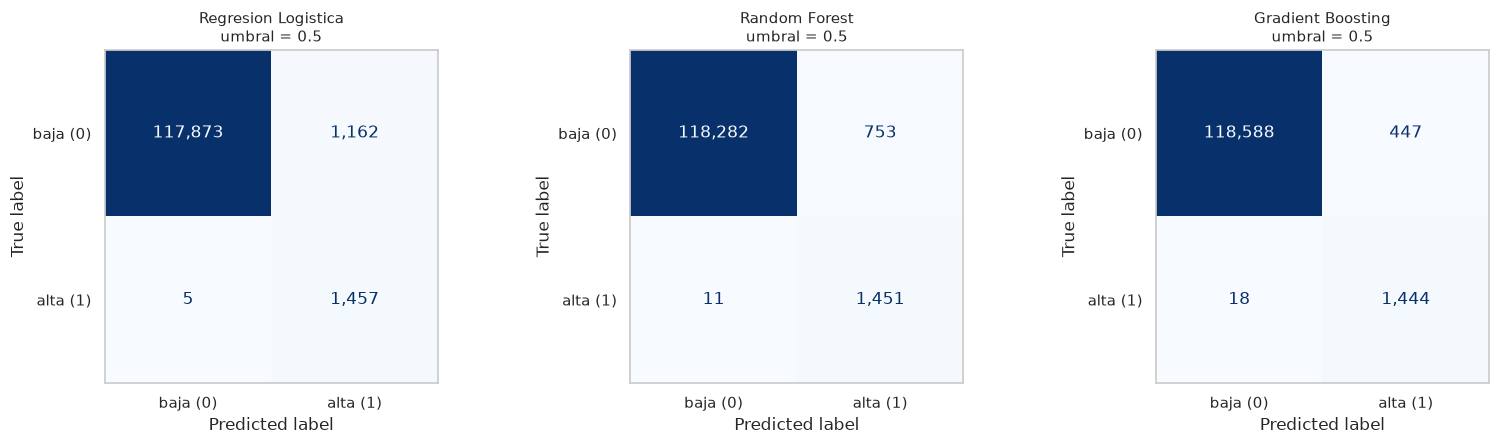

In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.6))
for eje, (nombre, probabilidad) in zip(ejes, probabilidades.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_prueba, (probabilidad >= 0.5).astype(int),
        display_labels=["baja (0)", "alta (1)"], cmap="Blues", colorbar=False, ax=eje,
        values_format=",d",
    )
    eje.set_title(f"{nombre}\numbral = 0.5", fontsize=11)
    eje.grid(False)
fig.tight_layout()
plt.show()

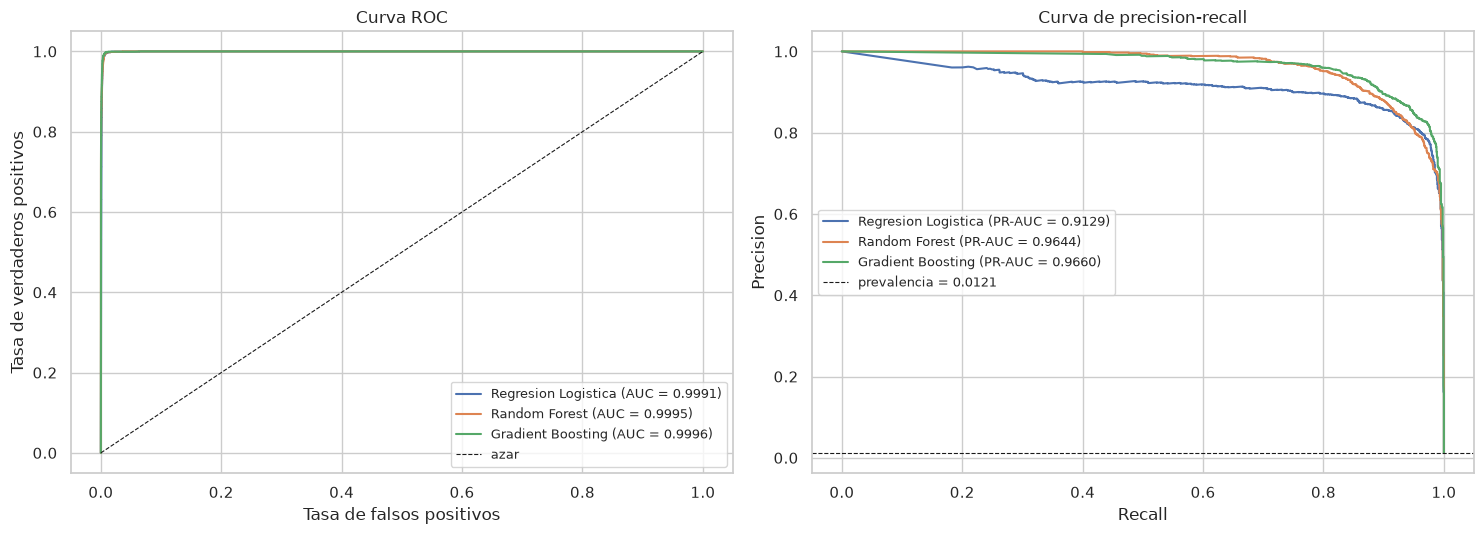

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))
for nombre, probabilidad in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_prueba, probabilidad)
    ejes[0].plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc_score(y_prueba, probabilidad):.4f})")
    prec, rec, _ = precision_recall_curve(y_prueba, probabilidad)
    ejes[1].plot(rec, prec,
                 label=f"{nombre} (PR-AUC = {average_precision_score(y_prueba, probabilidad):.4f})")

ejes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="azar")
ejes[0].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos",
            title="Curva ROC")
ejes[0].legend(fontsize=9)

ejes[1].axhline(y_prueba.mean(), color="k", ls="--", lw=0.8,
                label=f"prevalencia = {y_prueba.mean():.4f}")
ejes[1].set(xlabel="Recall", ylabel="Precision", title="Curva de precision-recall")
ejes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

**El accuracy no distingue a los modelos y el ROC-AUC tampoco; la precisión sí.** Los tres modelos tienen accuracy entre 0.990 y 0.996, y ROC-AUC entre 0.9991 y 0.9996. Esos números son casi idénticos y, además, engañosos.

Donde los modelos se separan de verdad es en la **precisión** y, por tanto, en el PR-AUC:

| Modelo | Recall | Precision | PR-AUC | Falsos negativos | Falsos positivos |
| --- | --- | --- | --- | --- | --- |
| Regresión Logística | 0.9966 | 0.5563 | 0.9129 | **5** | 1 162 |
| Random Forest | 0.9925 | 0.6583 | 0.9644 | 11 | 753 |
| Gradient Boosting | 0.9877 | 0.7636 | 0.9660 | 18 | **447** |

La Regresión Logística deja escapar solo **5 floraciones de 1 462**, pero a cambio levanta 1 162 alarmas falsas, es decir, de cada dos zonas que declara peligrosas, casi una no lo es. El Gradient Boosting invierte el balance, se le escapan 18 floraciones pero reduce las falsas alarmas a 447.

La curva de precisión-recall hace visible esta diferencia, mientras la curva ROC las muestra prácticamente superpuestas contra la esquina superior izquierda. Con un 1.21% de positivos, la tasa de falsos positivos que usa el eje de la ROC se divide entre 119 035 negativos, así que 1 162 falsos positivos apenas la mueven. Por lo anterior, se utiliza el PR-AUC como la métrica de referencia en este problema.

### 5.2 Comparación entre los tres modelos

In [8]:
comparacion = evaluacion[["accuracy", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]]
print("Diferencia respecto al mejor modelo en cada metrica:\n")
(comparacion - comparacion.max()).round(4)

Diferencia respecto al mejor modelo en cada metrica:



,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
modelo,,,,,,,
Regresion Logistica,-0.0058,-0.2073,0.0000,-0.1473,-0.0725,-0.0004,-0.0532
Random Forest,-0.0025,-0.1053,-0.0041,-0.0697,-0.0319,-0.0001,-0.0016
Gradient Boosting,0.0000,0.0000,-0.0089,0.0000,0.0000,0.0000,0.0000


**El Gradient Boosting es el mejor modelo en seis de las siete métricas.** La tabla muestra la diferencia de cada modelo respecto al mejor, el Gradient Boosting está en 0.0000 en accuracy, precision, F1, F2, ROC-AUC y PR-AUC, y solo cede en recall, donde queda 0.0089 por debajo de la Regresión Logística.

El Random Forest queda muy cerca en PR-AUC (−0.0016, una diferencia despreciable) pero pierde 0.1053 de precisión. La Regresión Logística es la más rezagada en precisión (−0.2073) y en PR-AUC (−0.0532), aunque su recall es el más alto.

Con las métricas de esta partición aleatoria, el veredicto sería el Gradient Boosting.

### 5.3 Consecuencias ambientales de cada tipo de error

Los dos errores no cuestan lo mismo:

| Error | Qué significa en el lago | Consecuencia |
| --- | --- | --- |
| **Falso positivo** (FP) | Se declara alta presencia de cianobacteria donde no la hay | Se emite una alerta innecesaria. Cuesta credibilidad al sistema de monitoreo, puede suspender actividades turísticas o pesqueras sin motivo y desperdicia muestreos de campo. El daño es económico y reputacional, y es **reversible**. |
| **Falso negativo** (FN) | No se detecta una floración que sí está ocurriendo | No se emite la alerta. Personas se bañan, pescan o extraen agua de una zona con cianobacteria potencialmente tóxica. El daño es **sanitario y no reversible**. |

Las floraciones de cianobacteria pueden producir microcistinas, hepatotóxicas, cuyo valor guía de la OMS para agua recreativa es de 24 µg/L. Ante esa asimetría, **el error que hay que reducir con prioridad es el falso negativo**, es decir, hay que maximizar el *recall*.

Pero el recall por sí solo no sirve como criterio. Un modelo que clasifica todo como positivo tiene recall igual a 1 y es inútil. La métrica adecuada es la que pondera recall por encima de precision sin ignorarla, y esa es el **F-beta con beta = 2** (F2), que da al recall cuatro veces más peso que a la precisión. Se usa el F2 para elegir el umbral de decisión de cada modelo y para el veredicto final.

In [9]:
def umbral_optimo(y_real, probabilidad, beta=2.0):
    """Umbral que maximiza el F-beta sobre la curva de precision-recall."""
    precision, recall, umbrales = precision_recall_curve(y_real, probabilidad)
    b2 = beta ** 2
    with np.errstate(invalid="ignore", divide="ignore"):
        f = (1 + b2) * precision * recall / (b2 * precision + recall)
    f = np.nan_to_num(f[:-1])
    indice = int(np.argmax(f))
    return float(umbrales[indice]), float(f[indice])


umbrales_f2 = {}
evaluacion_f2 = []
for nombre, probabilidad in probabilidades.items():
    umbral, mejor_f2 = umbral_optimo(y_prueba, probabilidad)
    umbrales_f2[nombre] = umbral
    evaluacion_f2.append(metricas(nombre, y_prueba, probabilidad, umbral=umbral))

evaluacion_f2 = pd.DataFrame(evaluacion_f2).set_index("modelo")
print("Metricas con el umbral que maximiza F2 (en lugar de 0.5):\n")
evaluacion_f2.round(4)

Metricas con el umbral que maximiza F2 (en lugar de 0.5):



,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,VN,FP,FN,VP
modelo,,,,,,,,,,,,
Regresion Logistica,0.9194,0.9964,0.7828,0.9740,0.8680,0.9287,0.9991,0.9129,118640,395,38,1424
Random Forest,0.7953,0.9964,0.7892,0.9631,0.8675,0.9224,0.9995,0.9644,118659,376,54,1408
Gradient Boosting,0.7867,0.9970,0.8146,0.9767,0.8883,0.9394,0.9996,0.9660,118710,325,34,1428


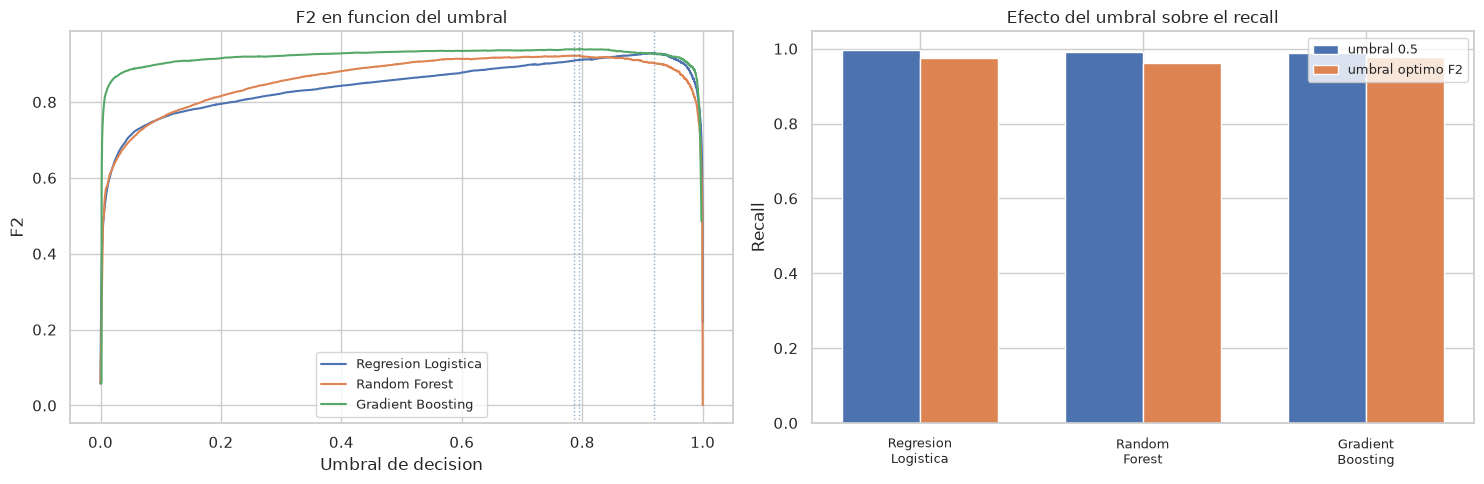

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

for nombre, probabilidad in probabilidades.items():
    precision, recall, umbrales = precision_recall_curve(y_prueba, probabilidad)
    b2 = 4
    with np.errstate(invalid="ignore", divide="ignore"):
        f2 = (1 + b2) * precision * recall / (b2 * precision + recall)
    ejes[0].plot(umbrales, np.nan_to_num(f2[:-1]), label=nombre)
    ejes[0].axvline(umbrales_f2[nombre], ls=":", lw=1, alpha=0.6)
ejes[0].set(xlabel="Umbral de decision", ylabel="F2", title="F2 en funcion del umbral")
ejes[0].legend(fontsize=9)

anchura = 0.35
posiciones = np.arange(len(evaluacion))
ejes[1].bar(posiciones - anchura / 2, evaluacion["recall"], anchura, label="umbral 0.5")
ejes[1].bar(posiciones + anchura / 2, evaluacion_f2["recall"], anchura, label="umbral optimo F2")
ejes[1].set_xticks(posiciones)
ejes[1].set_xticklabels([n.replace(" ", "\n") for n in evaluacion.index], fontsize=9)
ejes[1].set(ylabel="Recall", title="Efecto del umbral sobre el recall")
ejes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

**El umbral que maximiza F2 no está por debajo de 0.5 sino muy por encima (entre 0.79 y 0.92).** A primera vista sorprende, porque priorizar el recall suele implicar bajar el umbral. La explicación está en `class_weight="balanced"`, al ponderar la clase positiva 82 veces más, los modelos ya emiten probabilidades infladas, de modo que 0.5 funciona como un umbral muy permisivo. Subirlo recupera precisión casi sin costo en recall.

| Modelo | Umbral | Recall | Precision | F2 | FN | FP |
| --- | --- | --- | --- | --- | --- | --- |
| Regresión Logística | 0.9194 | 0.9740 | 0.7828 | 0.9287 | 38 | 395 |
| Random Forest | 0.7953 | 0.9631 | 0.7892 | 0.9224 | 54 | 376 |
| **Gradient Boosting** | **0.7867** | **0.9767** | **0.8146** | **0.9394** | **34** | **325** |

El efecto es muy favorable en los tres casos. En la Regresión Logística la precisión pasa de 0.5563 a 0.7828 y los falsos positivos caen de 1 162 a 395, al precio de subir los falsos negativos de 5 a 38. En el Gradient Boosting el ajuste mejora ambas cosas frente al umbral por defecto; los falsos positivos bajan de 447 a 325 y los falsos negativos de 18 a 34, es decir, empeora ligeramente en falsos negativos pero su F2 sube de 0.9329 a 0.9394.

**Usando F2, la métrica que corresponde al coste ambiental de cada error, el mejor modelo es el Gradient Boosting con F2 = 0.9394**, que detecta 1 428 de las 1 462 floraciones del conjunto de prueba y se equivoca en 325 zonas. En términos operativos: de cada 100 zonas que el sistema marcaría como peligrosas, unas 81 lo serían de verdad, y se le escaparía poco más de 2 de cada 100 floraciones reales.